# Simulador de estrategias sobre CSVs de `registers/`

Este notebook carga un CSV con columnas como `timestamp`, `price`, `action` y `equity`, y permite correr cuatro simulaciones:

1. Réplica de las operaciones registradas.
2. Sin compra de oportunidad, pero con venta de pánico y compra de recuperación.
3. Sin venta de pánico ni compra de recuperación, pero con compra de oportunidad.
4. Solo compra y venta básica.

Todas parten de una cartera inicial de **1.000.000 USD**.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import List

import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.style.use("default")

c:\Users\diego\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\diego\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
DATA_DIR = Path("registers")
INITIAL_CASH = 1_000_000.0

COLOR_MAP = {
    "Compra": "red",
    "Venta": "green",
    "Venta pánico": "orange",
    "Compra recuperación": "purple",
    "Compra oportunidad": "blue",
}

In [3]:
def cargar_csv(csv_path: str | Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path).copy()
    if "timestamp" in df.columns:
        df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    else:
        df["timestamp"] = pd.RangeIndex(len(df))
    df = df.sort_values("timestamp").reset_index(drop=True)

    if "price" not in df.columns:
        raise ValueError("El CSV debe contener una columna llamada 'price'.")

    if "action" not in df.columns:
        df["action"] = "NO_ACTION"

    return df


def atr_like(prices: pd.Series, period: int = 14) -> pd.Series:
    prices = prices.astype(float)
    tr = prices.diff().abs()
    atr = tr.rolling(period, min_periods=1).mean()

    fallback = max(0.00015, float(prices.iloc[0]) * 0.0002)
    atr = atr.fillna(fallback).replace(0, fallback)
    return atr


def metricas_sinteticas_kelly(prices: list[float], up_f: float = 1.0002, down_f: float = 0.999995) -> tuple[float, float]:
    n = len(prices)
    if n < 5:
        return 0.4, min((up_f - 1) / (1 - down_f), 4.0)

    lookahead = max(8, min(24, n // 4))
    step = max(1, lookahead // 4)
    resultados = []

    for i in range(0, n - lookahead - 1, step):
        p0 = prices[i]
        tp = p0 * up_f
        sl = p0 * down_f
        cerrada = False

        for j in range(i + 1, min(i + lookahead + 1, n)):
            pj = prices[j]
            if pj >= tp:
                resultados.append(1)
                cerrada = True
                break
            elif pj <= sl:
                resultados.append(-1)
                cerrada = True
                break

        if not cerrada:
            resultados.append(1 if prices[min(i + lookahead, n - 1)] > p0 else -1)

    win_rate = resultados.count(1) / len(resultados) if resultados else 0.4
    win_loss_ratio = min((up_f - 1) / (1 - down_f), 4.0)
    return win_rate, win_loss_ratio


def calcular_kelly_stake(win_rate: float, win_loss_ratio: float, fraction: float = 0.25) -> float:
    f_star = (win_rate * win_loss_ratio - (1 - win_rate)) / win_loss_ratio if win_loss_ratio > 0 else -1

    if f_star <= 0:
        # Fallback prudente para que la simulación siga operando incluso con ruido.
        fallback_wr = max(win_rate, 0.35)
        fallback_wl = max(win_loss_ratio, 1.5)
        f_star = (fallback_wr * fallback_wl - (1 - fallback_wr)) / fallback_wl

    return max(0.02, min(f_star * fraction, 0.20))

In [4]:
@dataclass
class TradeEvent:
    timestamp: object
    price: float
    color: str
    label: str
    side: str
    qty: int


@dataclass
class SimulationResult:
    data: pd.DataFrame
    trades: list[TradeEvent]
    cash_series: list[float]
    equity_series: list[float]
    final_cash: float
    final_position: int
    final_equity: float
    stake: float
    win_rate: float
    win_loss_ratio: float

In [5]:
def simular_estrategia(
    df: pd.DataFrame,
    *,
    initial_cash: float = INITIAL_CASH,
    atr_period: int = 14,
    up_f: float = 1.0002,
    down_f: float = 0.999995,
    enable_panic: bool = True,
    enable_recovery: bool = True,
    enable_opportunity: bool = True,
    replay_actions: bool = False,
) -> SimulationResult:
    df = df.copy().reset_index(drop=True)
    prices = df["price"].astype(float).tolist()
    times = pd.to_datetime(df["timestamp"], errors="coerce").tolist()
    actions = df["action"].astype(str).str.upper().fillna("NO_ACTION").tolist()

    win_rate, win_loss_ratio = metricas_sinteticas_kelly(prices, up_f=up_f, down_f=down_f)
    stake = calcular_kelly_stake(win_rate, win_loss_ratio)

    atr = atr_like(df["price"], period=atr_period)

    cash = float(initial_cash)
    position = 0
    compras_seguidas = 0
    ventas_fallidas = 0
    esperando_recuperacion = False
    prev_high = None
    prev_low = None
    last_entry_price = None

    trades: list[TradeEvent] = []
    cash_series: list[float] = []
    equity_series: list[float] = []

    def registrar_trade(ts, price, color, label, side, qty):
        trades.append(TradeEvent(ts, float(price), color, label, side, int(qty)))

    def comprar(qty, price, ts, label, color):
        nonlocal cash, position, last_entry_price
        qty = int(qty)
        if qty <= 0:
            return False

        precio = float(price)
        max_qty = int(cash // precio)
        qty = min(qty, max_qty)
        if qty <= 0:
            return False

        cash -= qty * precio
        position += qty
        last_entry_price = precio
        registrar_trade(ts, price, color, label, "BUY", qty)
        return True

    def vender(qty, price, ts, label, color):
        nonlocal cash, position
        qty = int(min(qty, position))
        if qty <= 0:
            return False

        cash += qty * float(price)
        position -= qty
        registrar_trade(ts, price, color, label, "SELL", qty)
        return True

    def recalcular_niveles(i: int):
        nonlocal prev_high, prev_low
        d = float(atr.iloc[i]) * 0.3
        d = max(d, float(prices[i]) * 0.0001)
        prev_high = float(prices[i]) + d
        prev_low = float(prices[i]) - d

    for i, (ts, price, act) in enumerate(zip(times, prices, actions)):
        price = float(price)

        if prev_high is None or prev_low is None:
            recalcular_niveles(i)

        equity = cash + position * price
        qty_buy = int((equity * stake) / price)
        qty_sell = int(position * 0.9) if position > 100 else int(position)

        if replay_actions:
            # Replica de lo registrado en el CSV.
            if act in {"BUY", "COMPRA"}:
                comprar(qty_buy, price, ts, "Compra", COLOR_MAP["Compra"])
            elif act in {"SELL", "VENTA"}:
                vender(qty_sell, price, ts, "Venta", COLOR_MAP["Venta"])
            elif act in {"PANIC", "PANIC_SELL", "VENTA_PANICO", "PANICO", "SELL_PANIC"}:
                if position > 0:
                    vender(position, price, ts, "Venta pánico", COLOR_MAP["Venta pánico"])
                else:
                    registrar_trade(ts, price, COLOR_MAP["Venta pánico"], "Venta pánico", "SELL", 0)
                esperando_recuperacion = True
                last_entry_price = price
            elif act in {"RECOVERY", "COMPRA_RECUPERACION", "RECUPERACION", "BUY_RECOVERY"}:
                comprar(qty_buy, price, ts, "Compra recuperación", COLOR_MAP["Compra recuperación"])
                esperando_recuperacion = False
            elif act in {"OPPORTUNITY", "COMPRA_OPORTUNIDAD", "OPORTUNIDAD", "BUY_OPPORTUNITY"}:
                comprar(qty_buy, price, ts, "Compra oportunidad", COLOR_MAP["Compra oportunidad"])

            # Tras una operación registrada, reiniciamos el rango como hace el bot.
            prev_high, prev_low = None, None
            compras_seguidas = 0
            ventas_fallidas = 0

        else:
            if esperando_recuperacion and enable_recovery:
                trigger = (last_entry_price or price) * up_f
                if price >= trigger or price >= prev_high:
                    comprar(qty_buy, price, ts, "Compra recuperación", COLOR_MAP["Compra recuperación"])
                    esperando_recuperacion = False
                    compras_seguidas = 0
                    ventas_fallidas = 0
                    prev_high, prev_low = None, None

            elif price > prev_high:
                if position > 0:
                    vender(qty_sell, price, ts, "Venta", COLOR_MAP["Venta"])
                    compras_seguidas = 0
                    ventas_fallidas = 0
                else:
                    ventas_fallidas += 1
                    if enable_opportunity and ventas_fallidas >= 3:
                        comprar(qty_buy, price, ts, "Compra oportunidad", COLOR_MAP["Compra oportunidad"])
                        ventas_fallidas = 0
                        compras_seguidas = 0
                        prev_high, prev_low = None, None
                        equity = cash + position * price
                        cash_series.append(cash)
                        equity_series.append(equity)
                        continue

                prev_high, prev_low = None, None

            elif price < prev_low:
                ventas_fallidas = 0
                compras_seguidas += 1

                if enable_panic and compras_seguidas >= 3:
                    if position > 0:
                        vender(position, price, ts, "Venta pánico", COLOR_MAP["Venta pánico"])
                    else:
                        registrar_trade(ts, price, COLOR_MAP["Venta pánico"], "Venta pánico", "SELL", 0)

                    esperando_recuperacion = enable_recovery
                    last_entry_price = price
                    compras_seguidas = 0
                    prev_high, prev_low = None, None
                else:
                    comprar(qty_buy, price, ts, "Compra", COLOR_MAP["Compra"])
                    prev_high, prev_low = None, None

        equity = cash + position * price
        cash_series.append(cash)
        equity_series.append(equity)

    out = df.copy()
    out["sim_cash"] = cash_series
    out["sim_equity"] = equity_series

    return SimulationResult(
        data=out,
        trades=trades,
        cash_series=cash_series,
        equity_series=equity_series,
        final_cash=cash,
        final_position=position,
        final_equity=cash + position * prices[-1],
        stake=stake,
        win_rate=win_rate,
        win_loss_ratio=win_loss_ratio,
    )

In [6]:
def graficar_resultado(df: pd.DataFrame, resultado: SimulationResult, titulo: str):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 9), sharex=True)

    ax1.plot(df["timestamp"], df["price"], color="black", lw=1.6, alpha=0.8, label="Precio")
    ax1.set_title(titulo)
    ax1.set_ylabel("Precio")

    # Mostrar una sola vez cada etiqueta en la leyenda.
    vistos = set()
    for trade in resultado.trades:
        label = trade.label if trade.label not in vistos else None
        ax1.scatter(
            trade.timestamp,
            trade.price,
            s=90,
            color=trade.color,
            edgecolors="black",
            zorder=5,
            label=label,
        )
        vistos.add(trade.label)

    ax1.grid(True, alpha=0.2)
    ax1.legend(loc="best")

    ax2.plot(df["timestamp"], resultado.equity_series, lw=2, label="Equity simulada")
    ax2.set_ylabel("USD")
    ax2.set_xlabel("Tiempo")
    ax2.grid(True, alpha=0.2)
    ax2.legend(loc="best")

    fig.tight_layout()
    plt.show()
    return fig


def imprimir_resumen(nombre: str, resultado: SimulationResult):
    pnl = resultado.final_equity - INITIAL_CASH
    print(f"{nombre}")
    print(f"  Win rate estimado: {resultado.win_rate:.2%}")
    print(f"  W/L estimado:      {resultado.win_loss_ratio:.2f}")
    print(f"  Kelly stake:       {resultado.stake:.2%}")
    print(f"  Caja final:        ${resultado.final_cash:,.2f}")
    print(f"  Posición final:    {resultado.final_position}")
    print(f"  Equity final:      ${resultado.final_equity:,.2f}")
    print(f"  PnL:               ${pnl:,.2f}")
    print(f"  Trades:            {len(resultado.trades)}")
    print()

In [7]:
def simulacion_replica(csv_path: str | Path):
    df = cargar_csv(csv_path)
    res = simular_estrategia(df, replay_actions=True)
    imprimir_resumen(f"Réplica: {Path(csv_path).name}", res)
    graficar_resultado(df, res, f"Réplica de operaciones — {Path(csv_path).name}")
    return res


def simulacion_sin_compra_oportunidad(csv_path: str | Path):
    df = cargar_csv(csv_path)
    res = simular_estrategia(
        df,
        enable_panic=True,
        enable_recovery=True,
        enable_opportunity=False,
    )
    imprimir_resumen(f"Sin compra oportunidad: {Path(csv_path).name}", res)
    graficar_resultado(df, res, f"Sin compra oportunidad — {Path(csv_path).name}")
    return res


def simulacion_sin_panico_ni_recuperacion(csv_path: str | Path):
    df = cargar_csv(csv_path)
    res = simular_estrategia(
        df,
        enable_panic=False,
        enable_recovery=False,
        enable_opportunity=True,
    )
    imprimir_resumen(f"Sin pánico ni recuperación: {Path(csv_path).name}", res)
    graficar_resultado(df, res, f"Sin pánico ni recuperación — {Path(csv_path).name}")
    return res


def simulacion_basica(csv_path: str | Path):
    df = cargar_csv(csv_path)
    res = simular_estrategia(
        df,
        enable_panic=False,
        enable_recovery=False,
        enable_opportunity=False,
    )
    imprimir_resumen(f"Básica: {Path(csv_path).name}", res)
    graficar_resultado(df, res, f"Simulación básica — {Path(csv_path).name}")
    return res

,timestamp,price,action,equity
0,2026-05-08 13:47:41,1.364730,NO_ACTION,999442.72
1,2026-05-08 13:47:46,1.364750,NO_ACTION,999442.72
2,2026-05-08 13:47:51,1.364735,NO_ACTION,999442.72
3,2026-05-08 13:47:56,1.364735,NO_ACTION,999442.72
4,2026-05-08 13:48:01,1.364700,NO_ACTION,999442.72


Réplica: price_records_USDCAD.csv
  Win rate estimado: 28.57%
  W/L estimado:      4.00
  Kelly stake:       2.68%
  Caja final:        $970,535.90
  Posición final:    21594
  Equity final:      $999,999.83
  PnL:               $-0.17
  Trades:            3



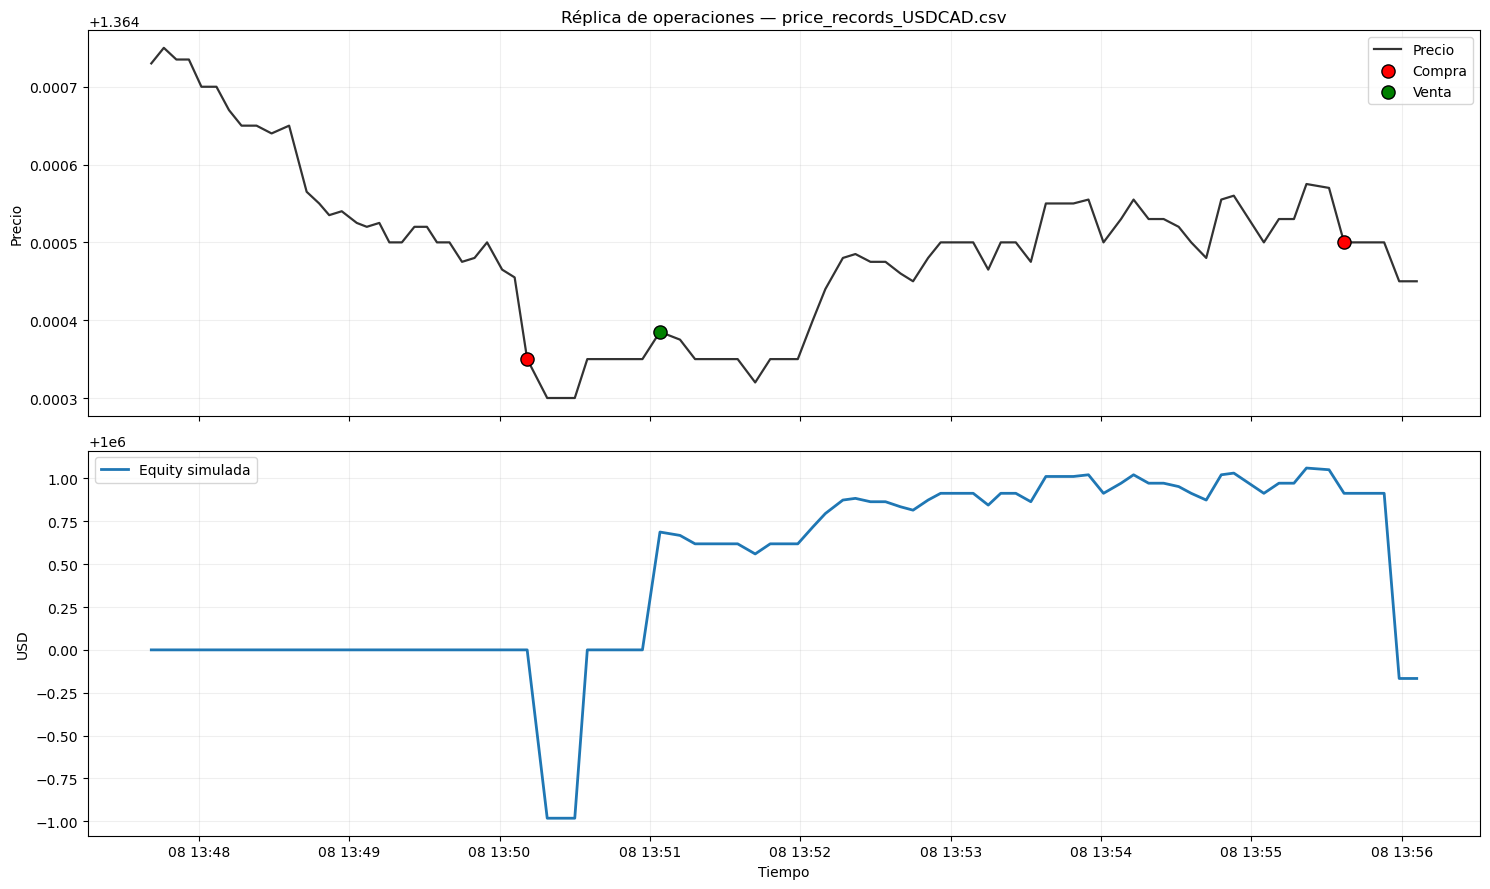

Sin compra oportunidad: price_records_USDCAD.csv
  Win rate estimado: 28.57%
  W/L estimado:      4.00
  Kelly stake:       2.68%
  Caja final:        $994,641.16
  Posición final:    3927
  Equity final:      $999,999.35
  PnL:               $-0.65
  Trades:            3



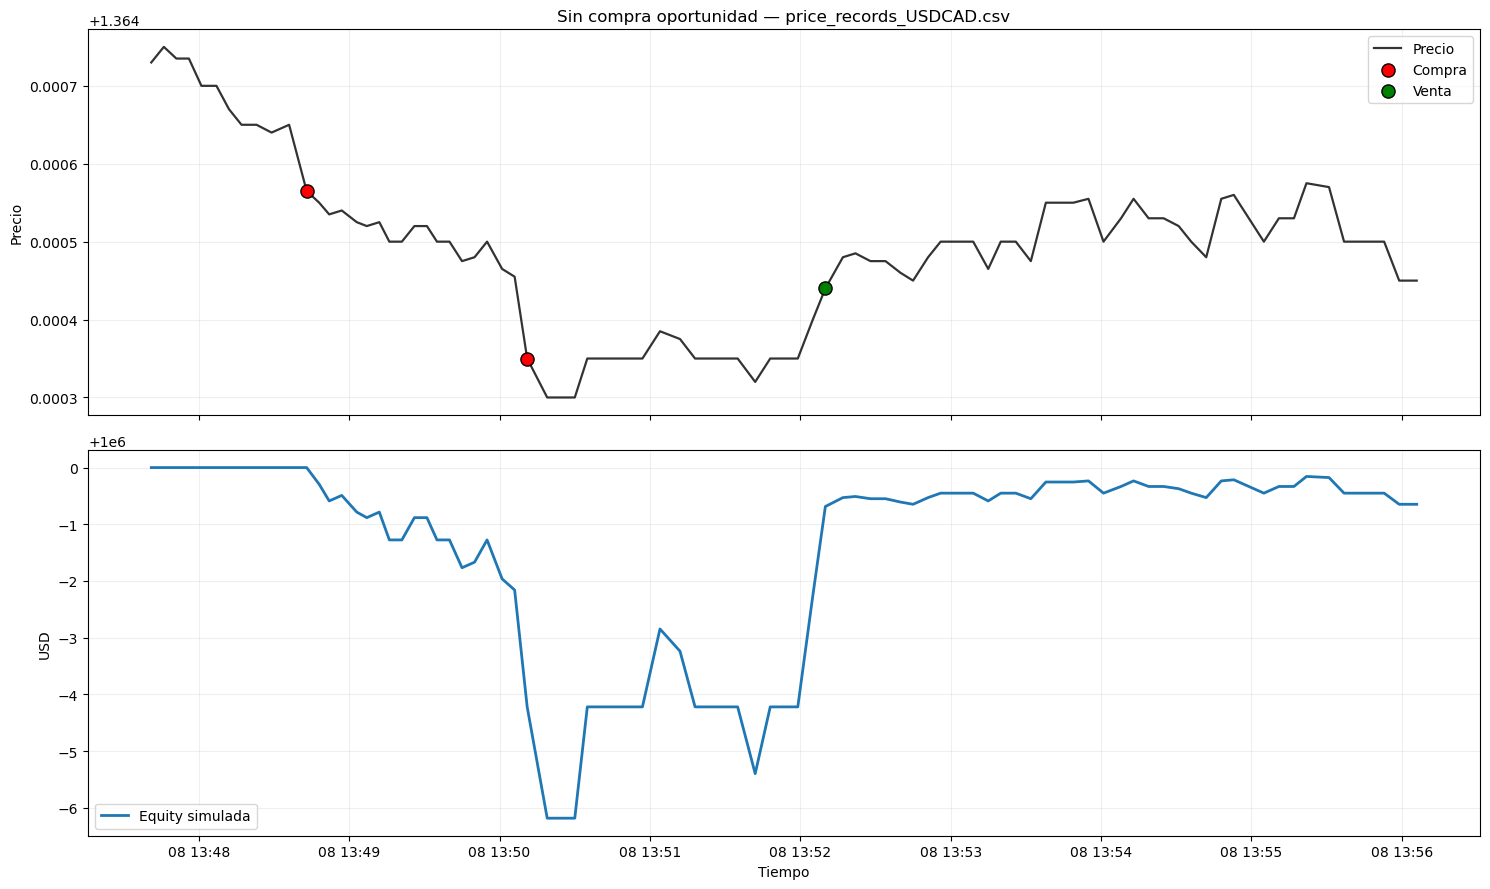

Sin pánico ni recuperación: price_records_USDCAD.csv
  Win rate estimado: 28.57%
  W/L estimado:      4.00
  Kelly stake:       2.68%
  Caja final:        $994,641.16
  Posición final:    3927
  Equity final:      $999,999.35
  PnL:               $-0.65
  Trades:            3



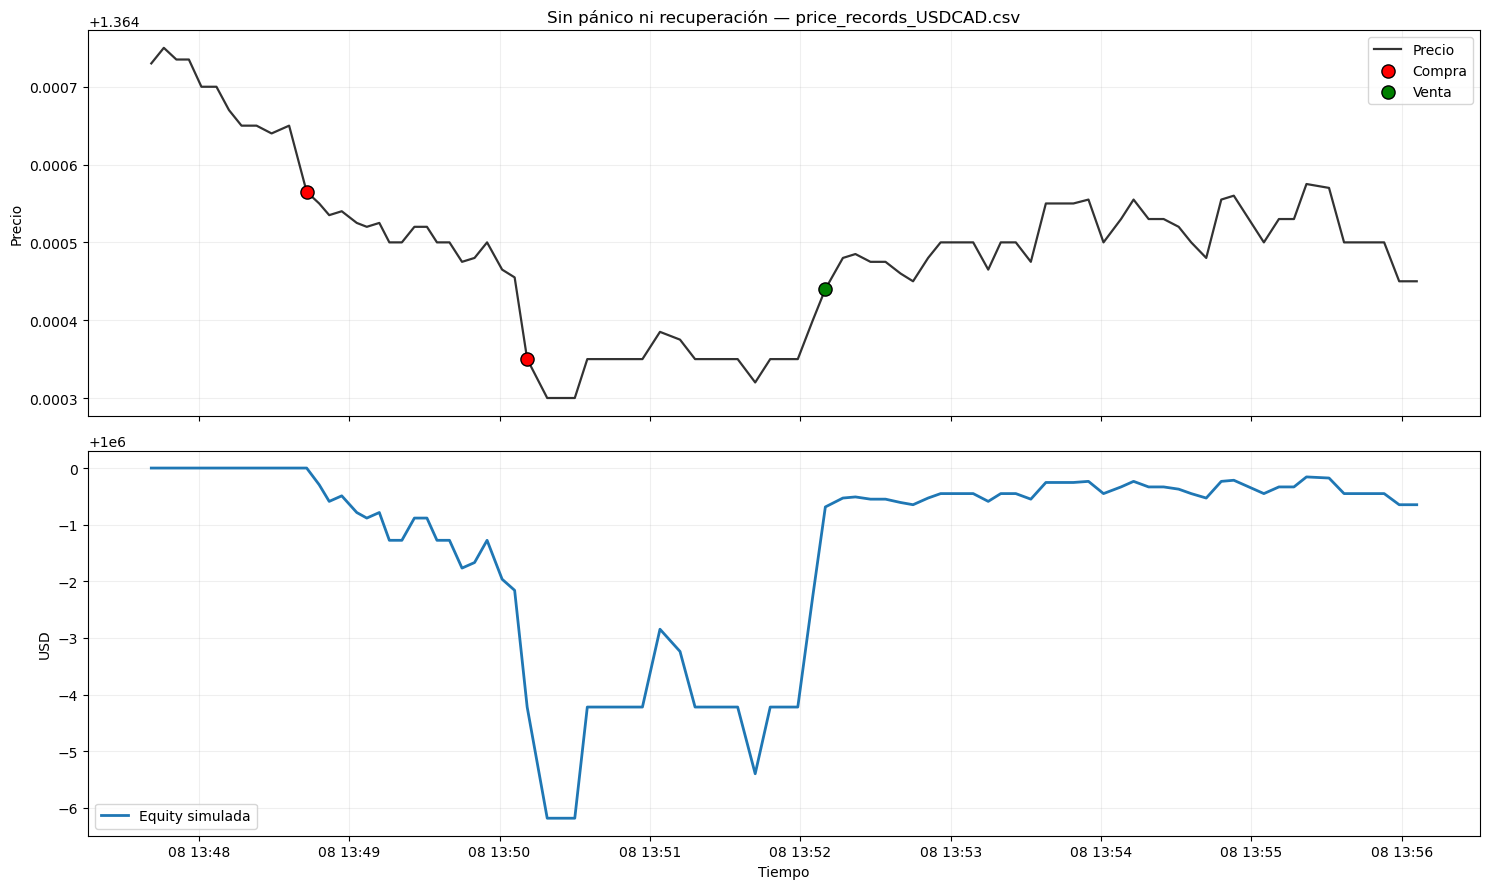

Básica: price_records_USDCAD.csv
  Win rate estimado: 28.57%
  W/L estimado:      4.00
  Kelly stake:       2.68%
  Caja final:        $994,641.16
  Posición final:    3927
  Equity final:      $999,999.35
  PnL:               $-0.65
  Trades:            3



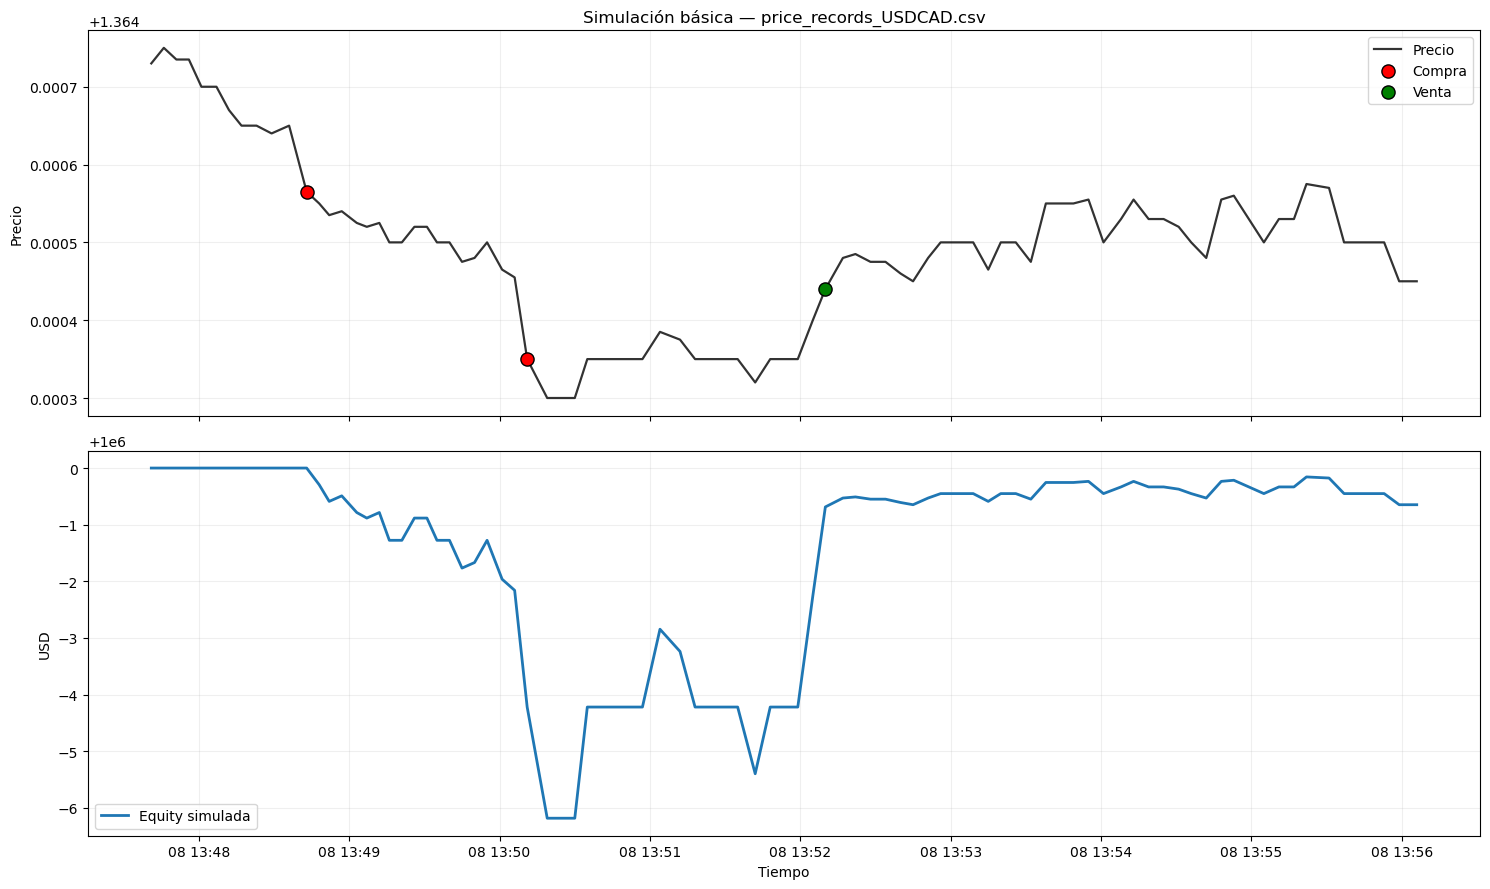

In [10]:
# Ejemplo de uso
# Cambia el archivo por el CSV que quieras analizar.
csv_path = DATA_DIR / "price_records_USDCAD.csv"

df_ejemplo = cargar_csv(csv_path)
display(df_ejemplo.head())

res_replica = simulacion_replica(csv_path)
res_sin_oportunidad = simulacion_sin_compra_oportunidad(csv_path)
res_sin_panico = simulacion_sin_panico_ni_recuperacion(csv_path)
res_basica = simulacion_basica(csv_path)


Procesando: price_records_EURCAD.csv
Básica: price_records_EURCAD.csv
  Win rate estimado: 38.46%
  W/L estimado:      4.00
  Kelly stake:       5.77%
  Caja final:        $994,237.20
  Posición final:    3594
  Equity final:      $1,000,007.19
  PnL:               $7.19
  Trades:            2



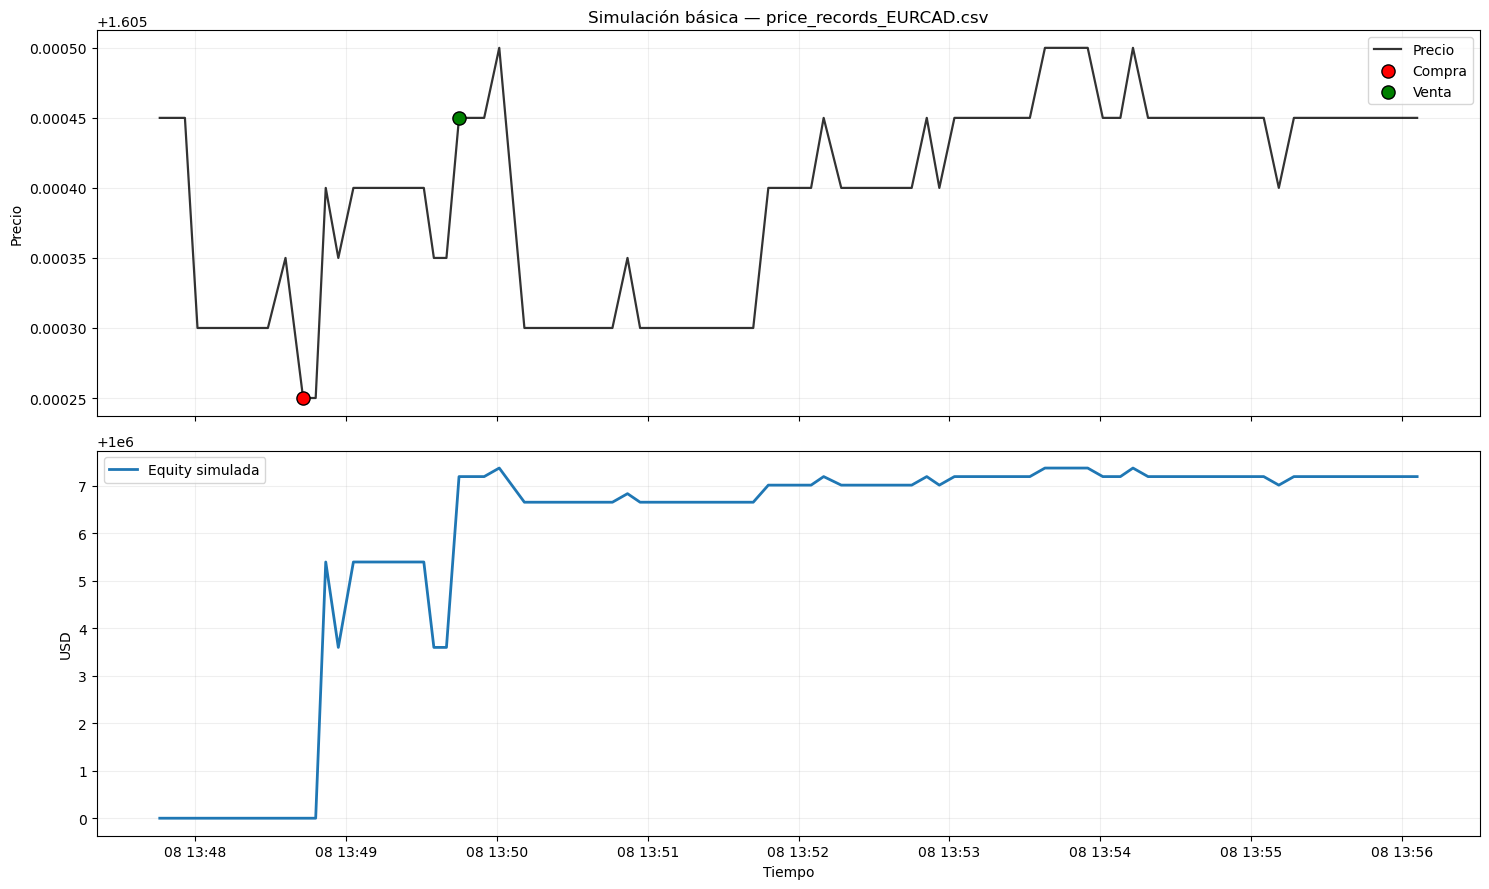


Procesando: price_records_EURUSD.csv
Básica: price_records_EURUSD.csv
  Win rate estimado: 28.57%
  W/L estimado:      4.00
  Kelly stake:       2.68%
  Caja final:        $999,735.53
  Posición final:    228
  Equity final:      $1,000,003.81
  PnL:               $3.81
  Trades:            3



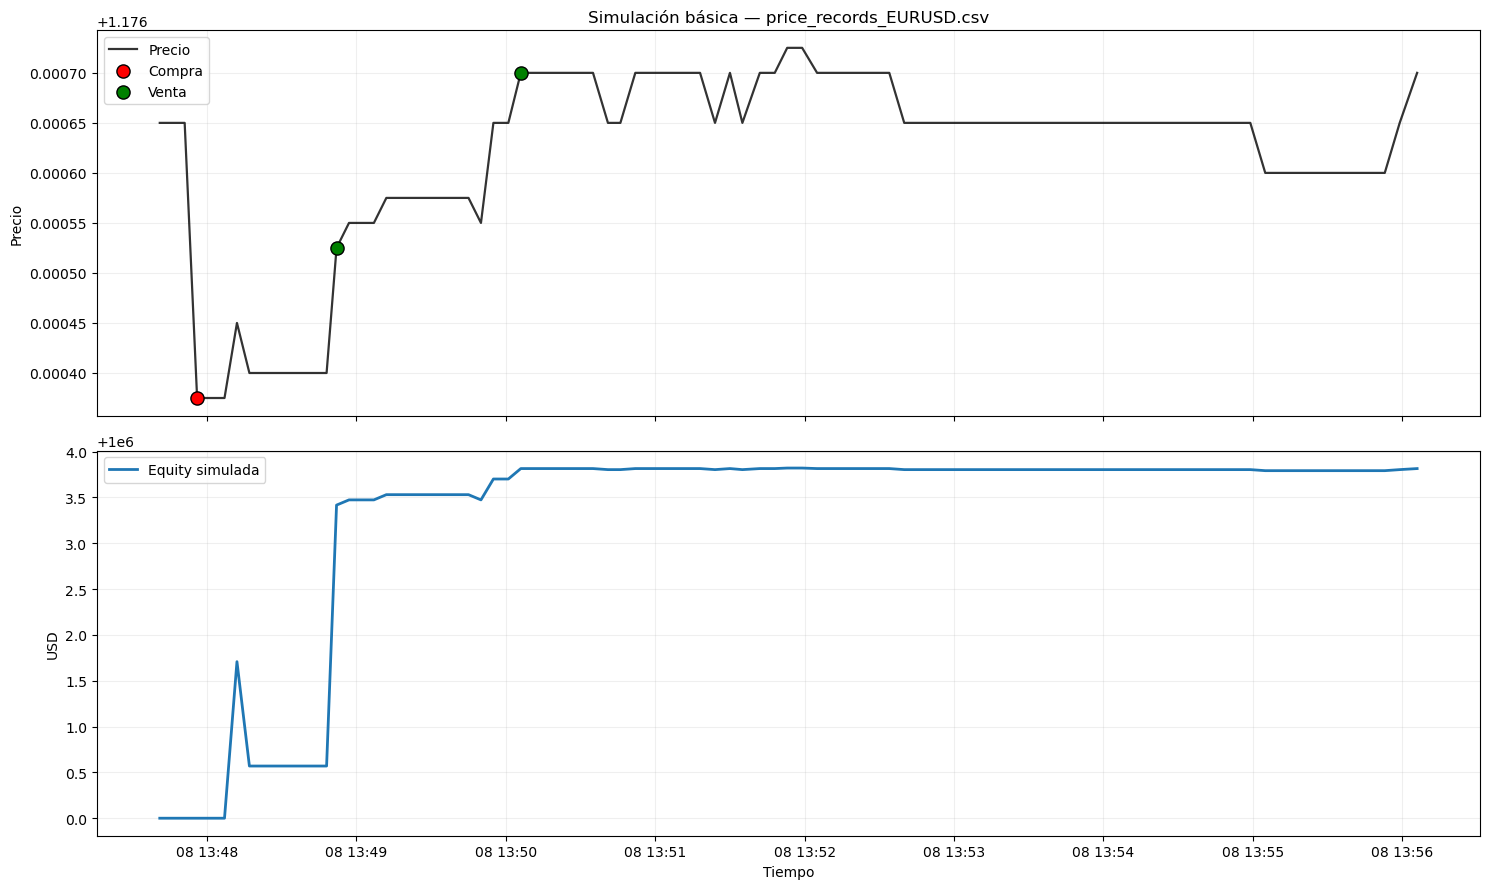


Procesando: price_records_USDCAD.csv
Básica: price_records_USDCAD.csv
  Win rate estimado: 28.57%
  W/L estimado:      4.00
  Kelly stake:       2.68%
  Caja final:        $994,641.16
  Posición final:    3927
  Equity final:      $999,999.35
  PnL:               $-0.65
  Trades:            3



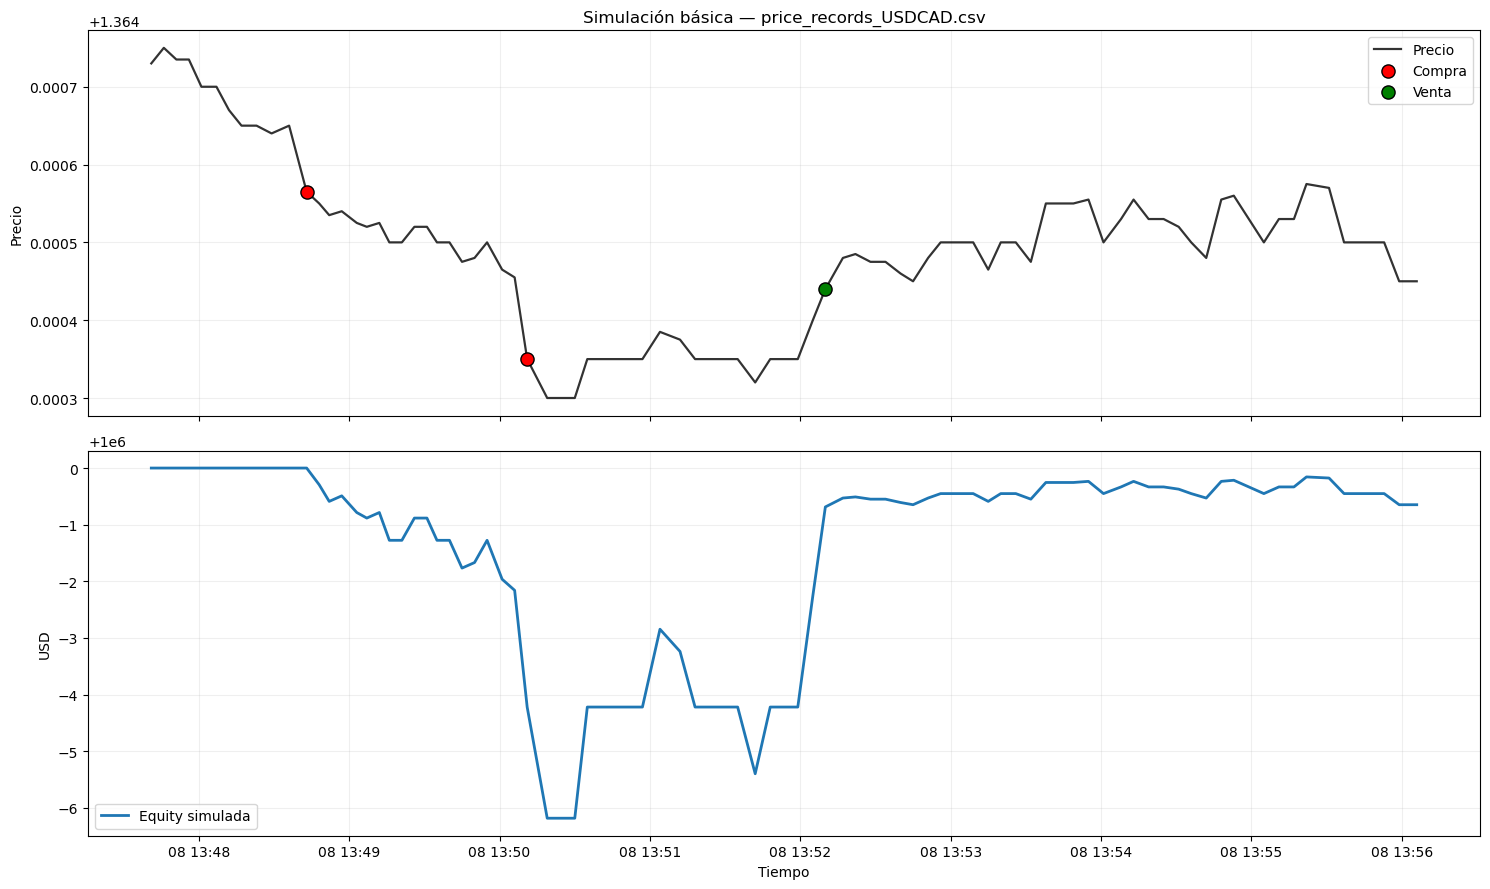

In [9]:
# Si quieres recorrer automáticamente todos los CSV de la carpeta:
for csv_file in sorted(DATA_DIR.glob("*.csv")):
    print(f"\nProcesando: {csv_file.name}")
    _ = simulacion_basica(csv_file)

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, FormatStrFormatter

# --- CONFIGURACIÓN VISUAL ---
def millions_formatter(x, pos):
    return f'${x/1e6:.2f}M'

def plot_simulacion(fechas, precios, wallet, operaciones, titulo):
    """Función auxiliar para graficar los resultados de cualquier simulación."""
    fig = plt.figure(figsize=(14, 10))
    ax1 = fig.add_subplot(2, 1, 1)
    ax2 = fig.add_subplot(2, 1, 2, sharex=ax1)

    # Panel 1: Precios y Operaciones
    ax1.plot(fechas, precios, color='black', lw=1, alpha=0.6, label='Precio Spot')
    
    # Mapeo de colores a descripciones para la leyenda
    legend_labels = {
        'red': 'Compra',
        'green': 'Venta',
        'orange': 'Venta Pánico',
        'purple': 'Compra Recuperación',
        'blue': 'Compra Oportunidad'
    }
    
    # Dibujar operaciones
    for op_f, op_p, op_c in operaciones:
        ax1.scatter(op_f, op_p, color=op_c, s=100, edgecolors='black', zorder=5)

    # Crear leyenda de puntos dinámicamente
    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, 
                          markersize=10, markeredgecolor='black', label=l) 
               for c, l in legend_labels.items() if any(op[2] == c for op in operaciones)]
    
    if handles:
        ax1.legend(handles=handles, loc='upper left')
        
    ax1.set_title(titulo, fontsize=14, fontweight='bold')
    ax1.set_ylabel("Precio")
    ax1.yaxis.set_major_formatter(FormatStrFormatter('%.5f'))
    ax1.grid(True, alpha=0.3)

    # Panel 2: Patrimonio Neto (Equity)
    ax2.plot(fechas, wallet, color='#1f77b4', lw=2)
    ax2.fill_between(fechas, wallet, min(wallet)*0.999, color='#1f77b4', alpha=0.1)
    ax2.set_title(f"Evolución del Patrimonio Neto - Final: ${wallet[-1]:,.2f}", fontsize=12, color='darkblue')
    ax2.set_ylabel("Valor Cuenta (USD)")
    ax2.yaxis.set_major_formatter(FuncFormatter(millions_formatter))
    ax2.grid(True, alpha=0.3)

    # Ocultar etiquetas X del panel 1 para mayor limpieza y rotar las del panel 2
    plt.setp(ax1.get_xticklabels(), visible=False)
    plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')
    
    # Reducir la cantidad de ticks en X si hay muchos datos
    if len(fechas) > 20:
        ax2.xaxis.set_major_locator(plt.MaxNLocator(20))

    fig.tight_layout()
    plt.show()


# --- 1. FUNCIÓN RÉPLICA ---
def simular_replica(ruta_csv):
    """
    1: Réplica exacta de las operaciones registradas en el CSV original.
    Utiliza las columnas 'action' y 'equity' del archivo.
    """
    df = pd.read_csv(ruta_csv)
    
    fechas = df['timestamp'].tolist()
    precios = df['price'].tolist()
    wallet = df['equity'].tolist()
    
    operaciones = []
    # Mapeo de acciones del CSV a colores
    color_map = {
        'BUY': 'red',
        'SELL': 'green',
        'PANIC_SELL': 'orange',
        'RECOVERY_BUY': 'purple',
        'OPPORTUNITY_BUY': 'blue'
    }
    
    for _, row in df.iterrows():
        accion = str(row['action']).upper()
        if accion in color_map:
            operaciones.append((row['timestamp'], row['price'], color_map[accion]))
            
    plot_simulacion(fechas, precios, wallet, operaciones, f"1. Réplica Exacta de Operaciones ({ruta_csv})")


# --- MOTOR DE SIMULACIÓN PARA FUNCIONES 2, 3 y 4 ---
def _motor_simulacion(ruta_csv, usa_panico=True, usa_oportunidad=True, usa_recuperacion=True, titulo="Simulación"):
    """Motor central que aplica tu lógica adaptada a datos estáticos."""
    df = pd.read_csv(ruta_csv)
    
    # Aproximación de ATR offline (Media móvil de los cambios absolutos de precio)
    df['atr_proxy'] = df['price'].diff().abs().rolling(window=14).mean().fillna(0.00015)
    
    capital = 1_000_000.0
    posicion = 0
    
    compras_seguidas = 0
    ventas_fallidas = 0 
    esperando_recuperacion = False
    
    UP_FACTOR, DOWN_FACTOR = 1.0002, 0.999995
    kelly_pct = 0.05 # Fijo al 5% para la simulación offline
    
    prev_high = None
    prev_low = None
    last_entry_price = 0
    
    fechas = []
    precios = []
    wallet = []
    operaciones = []
    
    for i, row in df.iterrows():
        current_price = row['price']
        date_str = row['timestamp']
        atr_val = row['atr_proxy']
        
        # Calcular Equity Actual
        equity_actual = capital + (posicion * current_price)
        
        fechas.append(date_str)
        precios.append(current_price)
        wallet.append(equity_actual)
        
        # 3. Gestión de Rangos
        if prev_high is None or prev_low is None:
            distancia = atr_val * 0.3 
            prev_high = current_price + distancia
            prev_low = current_price - distancia
            
        inversion_recomendada = equity_actual * kelly_pct
        cantidad_a_comprar = int(inversion_recomendada / current_price) if current_price > 0 else 0
        cantidad_a_vender = int(posicion * 0.9) if posicion > 100 else int(posicion)

        # --- LÓGICA DE TRADING ---
        if esperando_recuperacion and usa_recuperacion:
            if (current_price >= last_entry_price * UP_FACTOR) or (current_price >= prev_high):
                # Ejecutar Recuperación
                capital -= cantidad_a_comprar * current_price
                posicion += cantidad_a_comprar
                operaciones.append((date_str, current_price, 'purple'))
                
                esperando_recuperacion = False
                compras_seguidas = 0
                prev_high, prev_low = None, None

        elif current_price > prev_high:
            if posicion > 0:
                # Venta Normal
                capital += cantidad_a_vender * current_price
                posicion -= cantidad_a_vender
                operaciones.append((date_str, current_price, 'green'))
                
                ventas_fallidas = 0 
                compras_seguidas = 0
            else:
                ventas_fallidas += 1
                if ventas_fallidas >= 3 and usa_oportunidad:
                    # Ejecutar Oportunidad
                    capital -= cantidad_a_comprar * current_price
                    posicion += cantidad_a_comprar
                    operaciones.append((date_str, current_price, 'blue'))
                    ventas_fallidas = 0
                    
            prev_high, prev_low = None, None 

        elif current_price < prev_low:
            ventas_fallidas = 0
            compras_seguidas += 1
            
            if compras_seguidas < 3 or not usa_panico:
                # Compra Normal
                capital -= cantidad_a_comprar * current_price
                posicion += cantidad_a_comprar
                operaciones.append((date_str, current_price, 'red'))
                last_entry_price = current_price
            else:
                # Venta Pánico
                if posicion > 0:
                    capital += posicion * current_price
                    posicion = 0 # Vende todo
                operaciones.append((date_str, current_price, 'orange'))
                esperando_recuperacion = True
                
            prev_high, prev_low = None, None

    plot_simulacion(fechas, precios, wallet, operaciones, titulo)


# --- 2. FUNCIÓN SIN OPORTUNIDAD ---
def simular_sin_oportunidad(ruta_csv):
    """
    2: Sistema con Venta de Pánico y Compra de Recuperación. 
    IGNORA la Compra de Oportunidad.
    """
    _motor_simulacion(
        ruta_csv, 
        usa_panico=True, 
        usa_oportunidad=False, 
        usa_recuperacion=True, 
        titulo=f"2. Simulación Sin Compra de Oportunidad ({ruta_csv})"
    )

# --- 3. FUNCIÓN SIN PÁNICO / SOLO OPORTUNIDAD ---
def simular_sin_panico_ni_recuperacion(ruta_csv):
    """
    3: Sistema con Compra de Oportunidad. 
    IGNORA Venta de Pánico y Compra de Recuperación.
    """
    _motor_simulacion(
        ruta_csv, 
        usa_panico=False, 
        usa_oportunidad=True, 
        usa_recuperacion=False, # Si no hay pánico, no tiene sentido la recuperación
        titulo=f"3. Simulación Solo con Oportunidad (Sin Pánico) ({ruta_csv})"
    )

# --- 4. FUNCIÓN PURAMENTE BÁSICA ---
def simular_solo_basico(ruta_csv):
    """
    4: Sistema en nivel básico puro. 
    IGNORA Casos especiales (Pánico, Recuperación y Oportunidad).
    """
    _motor_simulacion(
        ruta_csv, 
        usa_panico=False, 
        usa_oportunidad=False, 
        usa_recuperacion=False, 
        titulo=f"4. Simulación Básica (Solo Compras y Ventas Normales) ({ruta_csv})"
    )

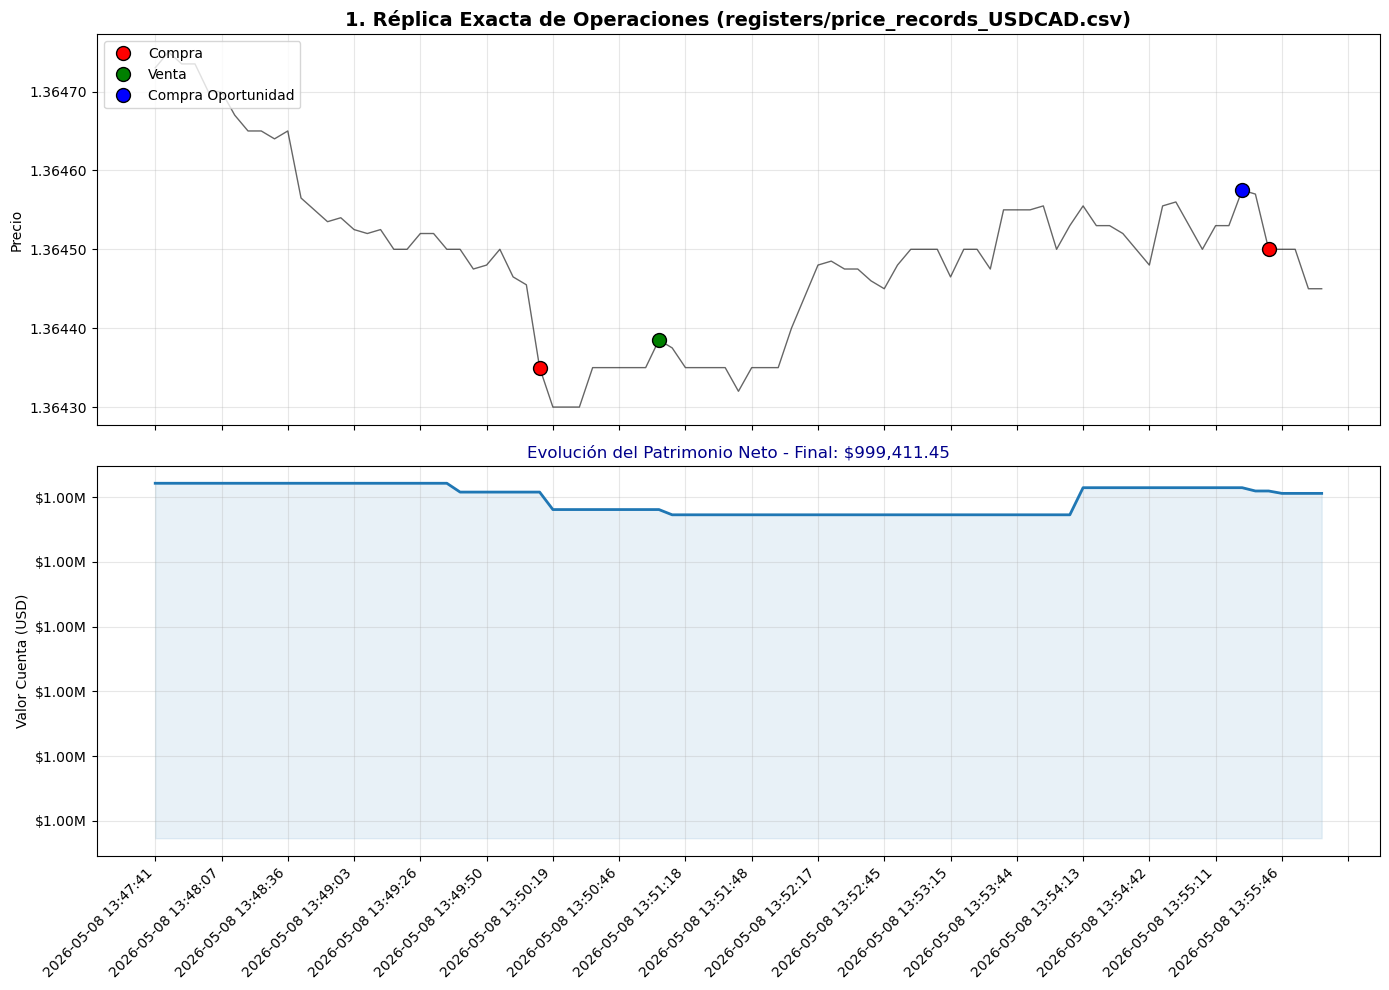

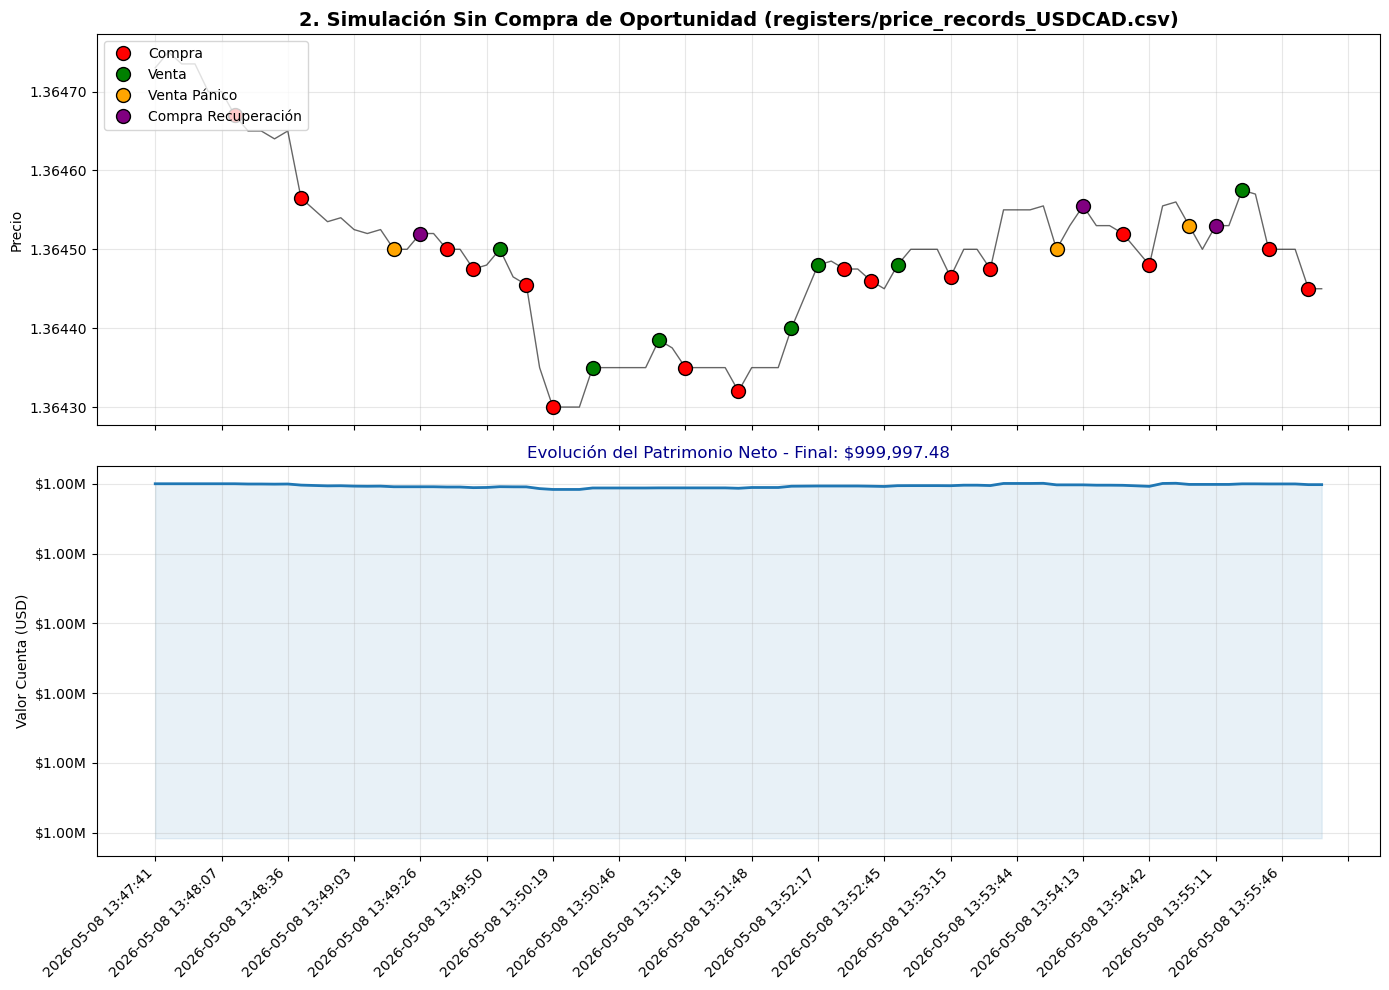

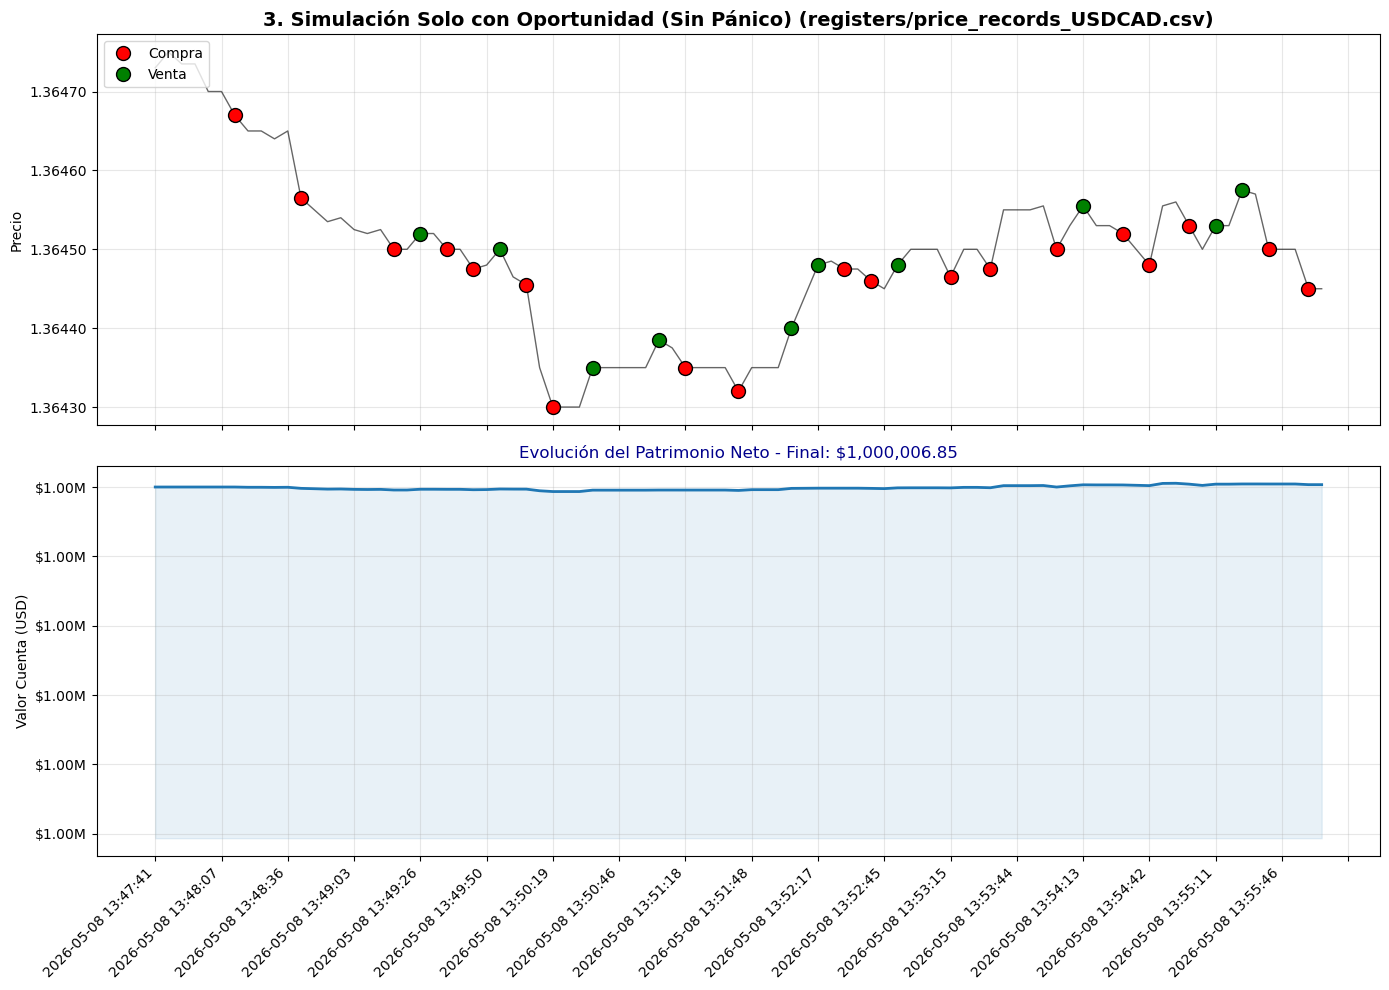

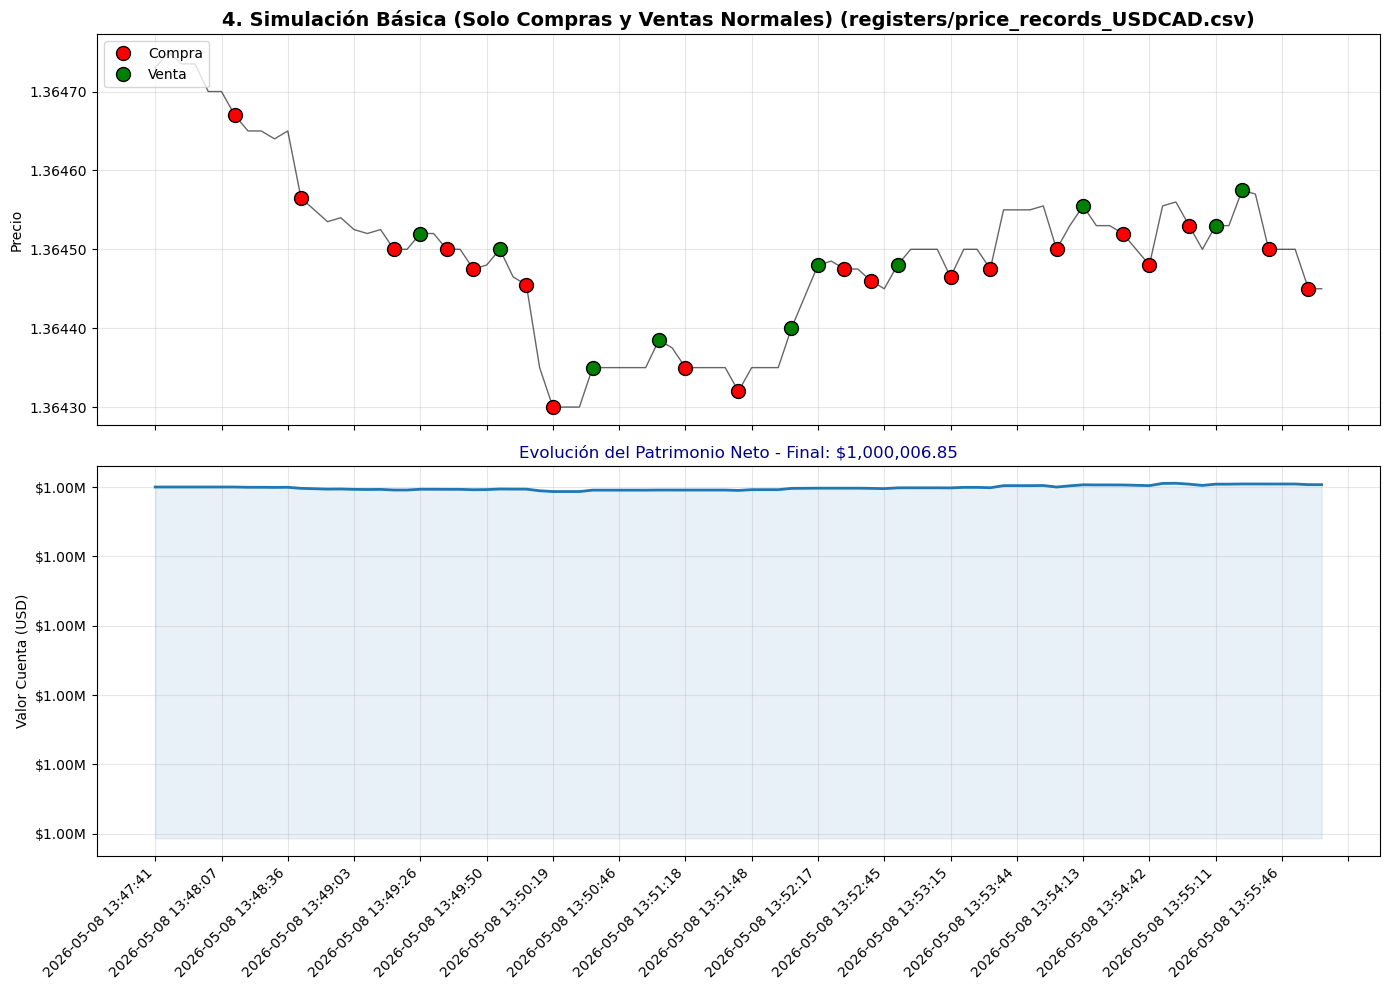

In [13]:
# Define la ruta a uno de tus archivos
archivo_prueba = 'registers/price_records_USDCAD.csv'

# Ejecuta las 4 simulaciones para comparar
simular_replica(archivo_prueba)
simular_sin_oportunidad(archivo_prueba)
simular_sin_panico_ni_recuperacion(archivo_prueba)
simular_solo_basico(archivo_prueba)